In [8]:
import os
import re
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-cache"))

warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")
warnings.filterwarnings("ignore", message="IProgress not found.*")
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except Exception:
    pass

import graphviz
import numpy as np
import pandas as pd
import statsmodels.api as sm
from dowhy import CausalModel
from IPython.display import display
from sklearn.preprocessing import RobustScaler

In [9]:
TOOL_NAME = 'CryptoGuard'
INPUT_FILE = 'alerts_with_lib_category_and_apk_size_cryptoguard.csv'
SMALL_LIBS = ['SocialMedia', 'Analytics', 'Cloud']
COMMON_CAUSES = ['apk_size_scaled', 'app_popularity_encoded']
METHOD_NAME = 'backdoor.generalized_linear_model'
CATEGORY_ORDER = ['<100', '100-500', '500-1k', '1k-5k', '5k-10k', '10k-50k', '50k-100k', '100k-500k', '500k-1M', '1M-5M', '>5M']
CAUSAL_GRAPH = '\ndigraph {\n    combined -> verdict;\n    apk_size_scaled -> combined;\n    apk_size_scaled -> verdict;\n    app_popularity_encoded -> combined;\n    app_popularity_encoded -> verdict;\n}\n'

In [10]:
def normalize_verdict(value):
    normalized = str(value).strip().lower()
    if normalized in {"1", "true"}:
        return 1
    if normalized in {"0", "false"}:
        return 0
    raise ValueError(f"Unsupported verdict value: {value!r}")


def normalize_rule_id(value):
    if pd.isna(value):
        return "missing"
    value = str(value).strip()
    if not value:
        return "missing"
    return re.sub(r"[^0-9A-Za-z_]+", "_", value)


def make_pairwise_balanced(df_in, lib_name, baseline="App_Source_Code", random_state=100):
    df_sub = df_in[df_in["lib_grouped"].isin([baseline, lib_name])].copy()
    baseline_df = df_sub[df_sub["lib_grouped"] == baseline]
    lib_df = df_sub[df_sub["lib_grouped"] == lib_name]
    target_count = len(baseline_df)

    if target_count == 0:
        raise ValueError("No App_Source_Code rows found for the baseline group.")
    if len(lib_df) == 0:
        raise ValueError(f"No rows found for library group: {lib_name}")

    if len(lib_df) >= target_count:
        lib_balanced = lib_df.sample(n=target_count, replace=False, random_state=random_state)
    else:
        lib_balanced = lib_df.sample(n=target_count, replace=True, random_state=random_state)

    df_balanced = pd.concat([baseline_df.copy(), lib_balanced], axis=0)
    return df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)


def print_refutation(method, ref):
    print(f"\nRefuter: {method}")
    if isinstance(ref, list):
        for item in ref:
            print(item)
    else:
        print(ref)


def get_refutation_value(ref, attribute):
    if isinstance(ref, list):
        return [getattr(item, attribute, None) for item in ref]
    return getattr(ref, attribute, None)


def get_confidence_interval(estimate):
    try:
        ci = np.asarray(estimate.get_confidence_intervals()).reshape(-1)
        if len(ci) >= 2:
            return float(ci[0]), float(ci[-1])
    except Exception:
        pass
    return None, None

In [11]:
df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].apply(normalize_verdict)
df["is_3rd_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["is_third_party"] = df["is_3rd_party"]

rule_id_source_column = "rule_id" if "rule_id" in df.columns else "ruleId"
if rule_id_source_column in df.columns:
    df["rule_id"] = df[rule_id_source_column].apply(normalize_rule_id)

popularity_column = "app_popularity" if "app_popularity" in df.columns else "apk_category"
df["app_popularity_encoded"] = pd.Categorical(
    df[popularity_column],
    categories=CATEGORY_ORDER,
    ordered=True,
).codes

df = df[df["app_popularity_encoded"] >= 0].copy()
df = df.dropna(subset=["apk_size", "verdict", "app_popularity_encoded"]).copy()

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

df["lib_grouped"] = df["code_location"].replace(SMALL_LIBS, "Small_Libraries")
df.loc[df["lib_grouped"] == "developer_written", "lib_grouped"] = "App_Source_Code"
df.loc[df["lib_grouped"] == "others", "lib_grouped"] = "miscellaneous"

df = df.drop(columns=["propensity_score"], errors="ignore").copy()

baseline_name = "App_Source_Code"
libs = [baseline_name] + [lib for lib in df["lib_grouped"].unique() if lib != baseline_name]

print("Popularity column:", popularity_column)
print("Grouped library counts:")
print(df["lib_grouped"].value_counts())
print("\nLibrary levels:")
for lib in libs:
    print("-", lib)

Original rows: 15272
After removing obfuscated: 15272
Popularity column: apk_category
Grouped library counts:
lib_grouped
Android            6678
miscellaneous      4044
Utilities          2681
App_Source_Code    1318
Small_Libraries     551
Name: count, dtype: int64

Library levels:
- App_Source_Code
- miscellaneous
- Android
- Utilities
- Small_Libraries


In [12]:
def apply_refutation_tests(lib_name, label, model, identified_estimand, estimate, ate):
    ref_rows = []
    refutation_methods = [
        "random_common_cause",
        "placebo_treatment_refuter",
        "data_subset_refuter",
        "dummy_outcome_refuter",
    ]

    for method in refutation_methods:
        try:
            if method == "placebo_treatment_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    placebo_type="permute",
                    num_simulations=200,
                )
            elif method == "data_subset_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    subset_fraction=0.8,
                    num_simulations=200,
                )
            elif method == "dummy_outcome_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    num_simulations=200,
                )
            else:
                ref = model.refute_estimate(identified_estimand, estimate, method_name=method)

            print_refutation(method, ref)
            ref_rows.append({
                "library": lib_name,
                "setting": label,
                "estimator": METHOD_NAME,
                "refuter": method,
                "estimated_effect": get_refutation_value(ref, "estimated_effect"),
                "new_effect": get_refutation_value(ref, "new_effect"),
                "p_value": get_refutation_value(ref, "p_value"),
                "error": None,
            })
        except Exception as exc:
            print(f"\nRefuter: {method}")
            print(f"Skipped because DoWhy could not run it for this estimand: {type(exc).__name__}: {exc}")
            ref_rows.append({
                "library": lib_name,
                "setting": label,
                "estimator": METHOD_NAME,
                "refuter": method,
                "estimated_effect": None,
                "new_effect": None,
                "p_value": None,
                "error": f"{type(exc).__name__}: {exc}",
            })
    return ref_rows


def run_library_contrast(df_sub, lib_name, baseline="App_Source_Code", label="balanced"):
    df_sub = df_sub.copy()
    df_sub["treatment_lib"] = (df_sub["lib_grouped"] == lib_name).astype(int)

    print("\n" + "-" * 14 + f" {lib_name} vs {baseline} " + "-" * 14)

    df_all = df_sub.copy()
    df_all["combined"] = 1
    df_baseline = df_sub[df_sub["treatment_lib"] == 0].copy()
    df_baseline["combined"] = 0
    df_sub = pd.concat([df_all, df_baseline], ignore_index=True)
    df_sub = df_sub.drop(columns=["propensity_score"], errors="ignore").copy()

    n0 = int((df_sub["combined"] == 0).sum())
    n1 = int((df_sub["combined"] == 1).sum())
    print(df_sub["combined"].value_counts().sort_index())
    display(graphviz.Source(CAUSAL_GRAPH))

    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=CAUSAL_GRAPH.replace("\n", " "),
        common_causes=COMMON_CAUSES,
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name=METHOD_NAME,
        target_units="ate",
        confidence_intervals="bootstrap",
        test_significance=True,
        method_params={
            "glm_family": sm.families.Binomial(),
            "predict_score": True,
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        },
    )

    ate = float(estimate.value)
    ci_low, ci_high = get_confidence_interval(estimate)

    print("ATE:", ate)
    if ci_low is not None:
        print("95% CI:", (ci_low, ci_high))

    ref_rows = apply_refutation_tests(lib_name, label, model, identified_estimand, estimate, ate)

    result_row = {
        "tool": TOOL_NAME,
        "library": lib_name,
        "setting": label,
        "estimator": METHOD_NAME,
        "n_baseline": n0,
        "n_treatment": n1,
        "common_causes": ", ".join(COMMON_CAUSES),
        "ATE": ate,
        "CI_low": ci_low,
        "CI_high": ci_high,
    }
    return result_row, ref_rows


-------------- miscellaneous vs App_Source_Code --------------
combined
0    1318
1    2636
Name: count, dtype: int64


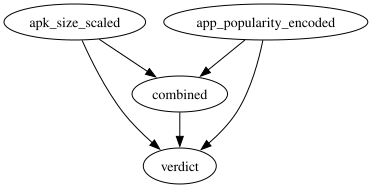

ATE: -0.016204348319359352
95% CI: (-0.052454843348606506, 0.01702306035948431)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.016204348319359352
New effect:-0.016182467794291656
p value:0.96


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.016204348319359352
New effect:-0.0007689065584044693
p value:0.92


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.016204348319359352
New effect:-0.01575006573074873
p value:0.99


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.00016724273664547572
p value:0.99


-------------- Android vs App_Source_Code --------------
combined
0    1318
1    2636
Name: count, dtype: int64


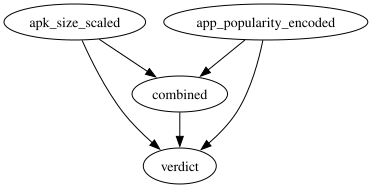

ATE: -0.07658388833622304
95% CI: (-0.1083936038141341, -0.04733034964795102)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.07658388833622304
New effect:-0.07661710691763361
p value:0.82


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.07658388833622304
New effect:-0.0008995918577887668
p value:0.97


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.07658388833622304
New effect:-0.07692891919911655
p value:0.91


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.0022810841452714963
p value:0.91


-------------- Utilities vs App_Source_Code --------------
combined
0    1318
1    2636
Name: count, dtype: int64


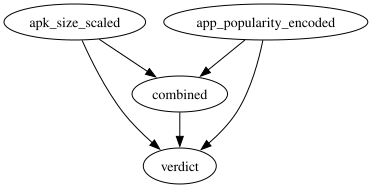

ATE: 0.11834290918012014
95% CI: (0.08419682380137383, 0.1478599984382709)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:0.11834290918012014
New effect:0.11830185222282964
p value:0.9


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:0.11834290918012014
New effect:-0.00017464783849910736
p value:0.99


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:0.11834290918012014
New effect:0.11772407289592621
p value:0.89


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.0020677617133090386
p value:0.935


-------------- Small_Libraries vs App_Source_Code --------------
combined
0    1318
1    2636
Name: count, dtype: int64


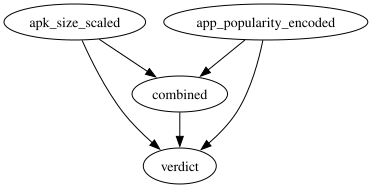

ATE: 0.12594130661017333
95% CI: (0.0947888456900346, 0.15628190012627607)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:0.12594130661017333
New effect:0.12590566229532787
p value:0.98


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:0.12594130661017333
New effect:0.0005320848612360369
p value:0.99


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:0.12594130661017333
New effect:0.1258336783035041
p value:0.96


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.0010282207155602734
p value:0.97



In [13]:
main_rows = []
ref_rows_all = []

for lib in libs:
    if lib == baseline_name:
        continue

    df_balanced = make_pairwise_balanced(df, lib, baseline=baseline_name, random_state=100)
    main_row, ref_rows = run_library_contrast(df_balanced, lib, baseline=baseline_name, label="balanced")
    main_rows.append(main_row)
    ref_rows_all.extend(ref_rows)

In [14]:
main_df = pd.DataFrame(main_rows)
ref_df = pd.DataFrame(ref_rows_all)

for table in [main_df, ref_df]:
    if not table.empty and "tool" not in table.columns:
        table.insert(0, "tool", TOOL_NAME)

if not main_df.empty:
    main_df = main_df.sort_values(["library", "setting"])

main_columns = [
    "tool",
    "library",
    "setting",
    "n_baseline",
    "n_treatment",
    "common_causes",
    "ATE",
    "CI_low",
    "CI_high",
]
ref_columns = [
    "tool",
    "library",
    "setting",
    "refuter",
    "estimated_effect",
    "new_effect",
    "p_value",
    "error",
]

print("\n\n" + "-" * 25 + " Detailed Logistic Regression Adjustment ATEs " + "-" * 25)
if main_df.empty:
    print("No main results available. Run the library-type contrast cell first.")
else:
    print(main_df[[column for column in main_columns if column in main_df.columns]])

print("\n\n" + "-" * 25 + " Refutations " + "-" * 25)
if ref_df.empty:
    print("No refutation results available. Run the library-type contrast cell first.")
else:
    print(ref_df[[column for column in ref_columns if column in ref_df.columns]])

main_df



------------------------- Detailed Logistic Regression Adjustment ATEs -------------------------
          tool          library   setting  n_baseline  n_treatment  \
1  CryptoGuard          Android  balanced        1318         2636   
3  CryptoGuard  Small_Libraries  balanced        1318         2636   
2  CryptoGuard        Utilities  balanced        1318         2636   
0  CryptoGuard    miscellaneous  balanced        1318         2636   

                             common_causes       ATE    CI_low   CI_high  
1  apk_size_scaled, app_popularity_encoded -0.076584 -0.108394 -0.047330  
3  apk_size_scaled, app_popularity_encoded  0.125941  0.094789  0.156282  
2  apk_size_scaled, app_popularity_encoded  0.118343  0.084197  0.147860  
0  apk_size_scaled, app_popularity_encoded -0.016204 -0.052455  0.017023  


------------------------- Refutations -------------------------
           tool          library   setting                    refuter  \
0   CryptoGuard    miscellaneous  ba

,tool,library,setting,estimator,n_baseline,n_treatment,common_causes,ATE,CI_low,CI_high
1,CryptoGuard,Android,balanced,backdoor.generalized_linear_model,1318,2636,"apk_size_scaled, app_popularity_encoded",-0.076584,-0.108394,-0.047330
3,CryptoGuard,Small_Libraries,balanced,backdoor.generalized_linear_model,1318,2636,"apk_size_scaled, app_popularity_encoded",0.125941,0.094789,0.156282
2,CryptoGuard,Utilities,balanced,backdoor.generalized_linear_model,1318,2636,"apk_size_scaled, app_popularity_encoded",0.118343,0.084197,0.147860
0,CryptoGuard,miscellaneous,balanced,backdoor.generalized_linear_model,1318,2636,"apk_size_scaled, app_popularity_encoded",-0.016204,-0.052455,0.017023
